# EDA корпуса ClassicLiteratureRAG

Корпус: «Преступление и наказание», «Идиот», «Бесы» (Достоевский), «Фауст» (пер. Н. Холодковского).
Вход — `data/processed/*.jsonl` после `scripts/download_texts.py` и `scripts/clean_texts.py`.

Цели EDA:
1. Проверить полноту и качество структурной разметки (части/главы/сцены).
2. Понять распределение длин записей — это основа выбора стратегии чанкинга.
3. Частотный анализ имён персонажей — источник словаря алиасов `configs/characters.yaml`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("../data/processed")
BOOKS = ["prestuplenie_i_nakazanie", "idiot", "besy", "faust_holodkovsky"]
TITLES = {
    "prestuplenie_i_nakazanie": "Преступление и наказание",
    "idiot": "Идиот",
    "besy": "Бесы",
    "faust_holodkovsky": "Фауст (Холодковский)",
}

df = pd.concat(
    [pd.read_json(DATA / f"{b}.jsonl", lines=True) for b in BOOKS], ignore_index=True
)
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()
df.head(3)

,book,part,chapter,chapter_title,section,scene,speaker,para_id,text,n_chars,n_words
0,prestuplenie_i_nakazanie,1,1,NaN,NaN,NaN,NaN,0,"В начале июля, в чрезвычайно жаркое время, под...",215,39
1,prestuplenie_i_nakazanie,1,1,NaN,NaN,NaN,NaN,1,Он благополучно избегнул встречи с своею хозяй...,646,97
2,prestuplenie_i_nakazanie,1,1,NaN,NaN,NaN,NaN,2,"Не то чтоб он был так труслив и забит, совсем ...",826,131


## 1. Сводка по корпусу

In [2]:
summary = (
    df.groupby("book")
    .agg(
        записей=("text", "size"),
        слов=("n_words", "sum"),
        медиана_слов=("n_words", "median"),
        p90_слов=("n_words", lambda s: int(s.quantile(0.9))),
        макс_слов=("n_words", "max"),
    )
    .loc[BOOKS]
)
summary.index = [TITLES[b] for b in summary.index]
summary

,записей,слов,медиана_слов,p90_слов,макс_слов
Преступление и наказание,3821,176249,20.0,111,2353
Идиот,4540,214266,20.0,112,4041
Бесы,5314,214693,18.0,93,1840
Фауст (Холодковский),1348,42263,16.0,73,857


## 2. Полнота структурной разметки

Число записей по частям — проверка, что ни одна часть не потеряна и объёмы правдоподобны.

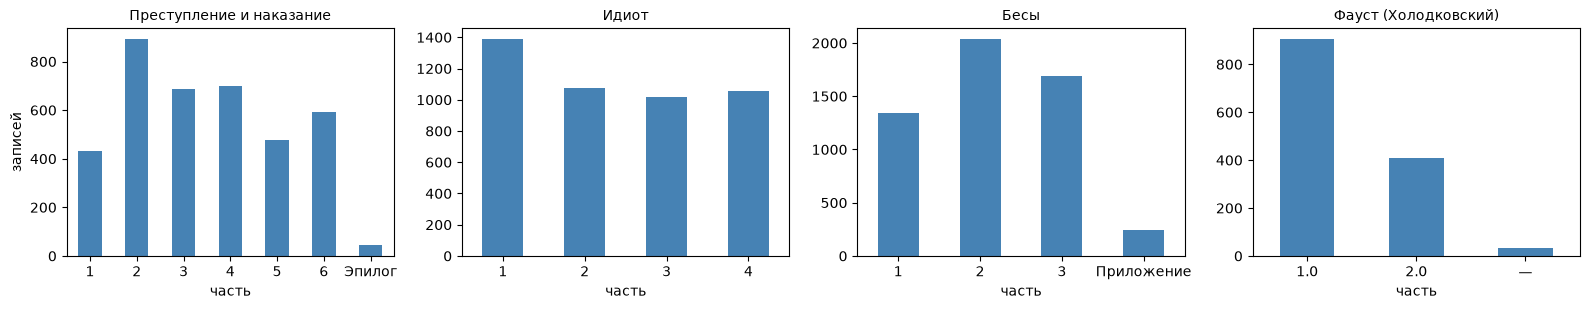

Преступление и наказание:
  часть 1: главы 1, 2, 3, 4, 5, 6, 7
  часть 2: главы 1, 2, 3, 4, 5, 6, 7
  часть 3: главы 1, 2, 3, 4, 5, 6
  часть 4: главы 1, 2, 3, 4, 5, 6
  часть 5: главы 1, 2, 3, 4, 5
  часть 6: главы 1, 2, 3, 4, 5, 6, 7, 8
  часть Эпилог: главы 1, 2
Идиот:
  часть 1: главы 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16
  часть 2: главы 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12
  часть 3: главы 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
  часть 4: главы 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, Заключение
Бесы:
  часть 1: главы 1, 2, 3, 4, 5
  часть 2: главы 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
  часть 3: главы 1, 2, 3, 4, 5, 6, 7, 8
  часть Приложение: главы 9


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, book in zip(axes, BOOKS, strict=True):
    sub = df[df["book"] == book]
    counts = sub["part"].fillna("—").value_counts().sort_index(key=lambda i: i.astype(str))
    counts.plot.bar(ax=ax, color="steelblue")
    ax.set_title(TITLES[book], fontsize=10)
    ax.set_xlabel("часть")
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("записей")
plt.tight_layout()
plt.show()


def chapter_key(x: str) -> tuple[bool, int]:
    return (not str(x).isdigit(), int(x) if str(x).isdigit() else 0)


# главы по частям (романы): убеждаемся в отсутствии дыр в нумерации
for book in BOOKS[:3]:
    sub = df[df["book"] == book]
    chapters = sub.groupby("part")["chapter"].apply(
        lambda s: sorted(s.dropna().unique(), key=chapter_key)
    )
    print(f"{TITLES[book]}:")
    for part, chs in chapters.items():
        print(f"  часть {part}: главы {', '.join(map(str, chs))}")

## 3. Распределение длин записей → выбор чанкинга

Единица корпуса — абзац (романы) / реплика («Фауст»). Для индексации важно,
сколько абзацев помещается в чанк и как часто встречаются сверхдлинные записи.

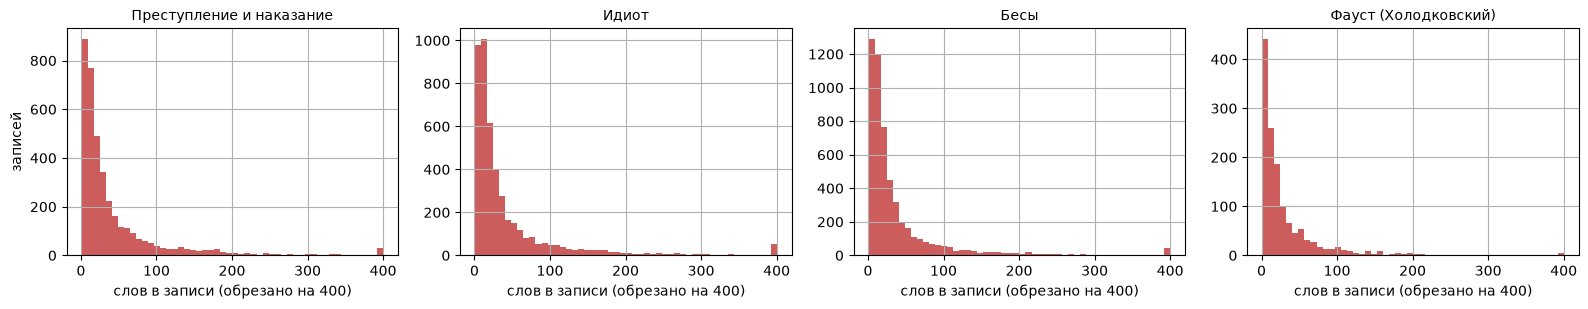

                           p50    p90    p99
Преступление и наказание  20.0  111.0  370.0
Идиот                     20.0  112.0  425.0
Бесы                      18.0   93.0  372.0
Фауст (Холодковский)      16.0   73.0  207.0

Доля записей длиннее 350 слов (не влезут в чанк целиком):
book
prestuplenie_i_nakazanie    1.1 %
idiot                       1.4 %
besy                        1.1 %
faust_holodkovsky           0.4 %
Name: n_words, dtype: str


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=False)
for ax, book in zip(axes, BOOKS, strict=True):
    sub = df[df["book"] == book]
    sub["n_words"].clip(upper=400).hist(bins=50, ax=ax, color="indianred")
    ax.set_title(TITLES[book], fontsize=10)
    ax.set_xlabel("слов в записи (обрезано на 400)")
axes[0].set_ylabel("записей")
plt.tight_layout()
plt.show()

pct = df.groupby("book")["n_words"].quantile([0.5, 0.9, 0.99]).unstack().loc[BOOKS]
pct.index = [TITLES[b] for b in pct.index]
pct.columns = ["p50", "p90", "p99"]
print(pct.round(0))

long_share = (df["n_words"] > 350).groupby(df["book"]).mean().loc[BOOKS]
print("\nДоля записей длиннее 350 слов (не влезут в чанк целиком):")
print((long_share * 100).round(1).astype(str) + " %")

## 4. Частоты имён персонажей

Считаем слова с заглавной буквы не в начале предложения (грубый NER без
моделей — достаточно для словаря алиасов). Для «Фауста» источник надёжнее —
поле `speaker` из разметки драмы.

In [5]:
import collections
import re

from razdel import sentenize, tokenize

STOP = {"Это", "Что", "Как", "Нет", "Так", "Вот", "Если", "Когда", "Кто", "Где",
        "Чтоб", "Всё", "Все", "Она", "Они", "Там", "Меня", "Мне", "Его", "Здесь",
        "Пусть", "Лишь", "Тебя", "Тебе", "Нам", "Чем", "Тот", "Ведь", "Петербурге"}

def name_freq(texts: pd.Series) -> collections.Counter:
    cnt: collections.Counter = collections.Counter()
    for text in texts:
        for sent in sentenize(text):
            toks = [t.text for t in tokenize(sent.text)]
            for t in toks[1:]:  # первое слово предложения пропускаем
                if len(t) >= 3 and re.match(r"^[А-ЯЁ][а-яё]+$", t) and t not in STOP:
                    cnt[t] += 1
    return cnt

top_names = {}
for book in BOOKS[:3]:
    cnt = name_freq(df.loc[df["book"] == book, "text"])
    top_names[book] = cnt.most_common(25)
    print(f"=== {TITLES[book]}")
    print(", ".join(f"{w} ({n})" for w, n in top_names[book]))
    print()

faust = df[df["book"] == "faust_holodkovsky"]
speakers = (
    faust["speaker"].dropna().str.replace(r"\s*\(.*\)$", "", regex=True).value_counts()
)
print("=== Фауст: реплики по говорящим (топ-20)")
print(speakers.head(20))

=== Преступление и наказание
Раскольников (353), Петрович (208), Разумихин (195), Соня (182), Ивановна (175), Раскольникова (126), Александровна (109), Дуня (104), Порфирий (103), Родя (99), Катерина (95), Свидригайлов (94), Петр (88), Пульхерия (86), Родион (84), Романовна (78), Авдотья (66), Раскольникову (57), Разумихина (56), Дунечка (55), Ивановны (54), Петровича (51), Романыч (48), Ивановне (46), Петровна (45)



=== Идиот
Аглая (236), Филипповна (235), Прокофьевна (204), Лебедев (199), Рогожин (191), Настасья (189), Ганя (158), Лизавета (156), Коля (131), Евгений (116), Павлович (115), Ипполит (112), Лебедева (110), Настасьи (87), Филипповны (85), Иван (83), Рогожина (81), Фердыщенко (72), Ардалионович (66), Федорович (63), Лев (61), Аделаида (61), Епанчиных (61), Ивановна (60), Аглаи (57)



=== Бесы
Степанович (386), Трофимович (332), Петр (293), Петровна (265), Всеволодович (254), Степан (248), Шатов (197), Николай (187), Варвара (186), Ставрогин (151), Кириллов (130), Липутин (115), Шатова (114), Степана (111), Трофимовича (111), Лембке (110), Михайловна (98), Николаевич (81), Лиза (79), Юлии (78), Лебядкин (77), Петра (73), Степановича (72), Юлия (70), Варвары (67)

=== Фауст: реплики по говорящим (топ-20)
speaker
Мефистофель    321
Фауст          275
Маргарита       74
Марта           41
Хор             38
Елена           32
Форкиада        26
Фрош            23
Альтмайер       21
Вагнер          19
Гретхен         18
Ученик          17
Брандер         17
Эвфорион        13
Ведьма          11
Валентин        11
Голос           10
Император       10
Астролог        10
Бакалавр        10
Name: count, dtype: int64


## 5. Покрытие словаря алиасов

Проверяем, что частотные имена из корпуса присутствуют в `configs/characters.yaml`
(как канон или алиас) — словарь пополнен по результатам этого анализа.

In [6]:
import yaml

chars = yaml.safe_load(Path("../configs/characters.yaml").read_text())

def known_tokens(book: str) -> set[str]:
    toks: set[str] = set()
    for canon, aliases in chars[book].items():
        for name in [canon, *aliases]:
            toks.update(name.replace("-", " ").split())
    return {t.strip(".,").casefold() for t in toks}

for book in BOOKS[:3]:
    known = known_tokens(book)
    top15 = [w for w, _ in top_names[book][:15]]
    missing = [w for w in top15 if w.casefold() not in known]
    covered = len(top15) - len(missing)
    print(f"{TITLES[book]}: покрыто {covered}/15 топ-имён; вне словаря: {missing}")

Преступление и наказание: покрыто 15/15 топ-имён; вне словаря: []
Идиот: покрыто 12/15 топ-имён; вне словаря: ['Лебедева', 'Настасьи', 'Филипповны']
Бесы: покрыто 12/15 топ-имён; вне словаря: ['Шатова', 'Степана', 'Трофимовича']


## Выводы

1. **Структура полная**: ПиН — 6 частей + эпилог, «Идиот» — 4 части (главы без
   пропусков), «Бесы» — 3 части + приложение «У Тихона», «Фауст» — 2 части,
   37 сцен. Мусор (шапки сайта, оглавления, комментарии изданий) отрезан
   (валидация — в `tests/test_cleaning.py`).
2. **Длины**: распределение сильно скошено. Медиана записи всего ~16–20 слов
   (короткие реплики диалогов), p90 ~110, и при этом ~1% записей длиннее
   350 слов (абзацы-монологи до 2–4 тыс. слов). Значит, чанкинг
   «абзац = чанк» не годится с обеих сторон: короткие реплики без контекста
   бесполезны для retrieval, а монологи не влезают в окно эмбеддера
   (e5-base — 512 токенов). Нужны (а) окна с перекрытием, склеивающие
   соседние абзацы, и (б) разрезание сверхдлинных абзацев по предложениям.
   Кандидаты для сравнения в eval: окна ~256 и ~512 токенов против чанков
   по границам глав; для «Фауста» — реплики со склейкой коротких соседей
   внутри сцены.
3. **Имена**: частотный анализ подтвердил словарь алиасов и добавил в него
   второй ряд персонажей (Лебедев, Лембке, Лужин, Марта и др.). Остаточные
   «непокрытые» токены — падежные формы уже включённых персонажей
   («Шатова», «Настасьи») — их покроет морфологическая нормализация запроса
   на этапе retrieval, а не словарь. Известная омонимия: Верховенский
   отец/сын («Бесы»), сёстры Епанчины — учитывается в нормализаторе
   и обсуждается в decisions.md.